# Aula 3 - Gráficos com Plotly
- Gráficos com Plotly

## Gráficos com Plotly
O módulo *plotly.express* (geralmente importado como px) contém funções que podem criar figuras inteiras de uma só vez e é chamado de Plotly Express ou PX.

Plotly Express é uma parte interna da biblioteca plotly, e é o ponto de partida recomendado para a criação de figuras mais comuns. Cada função Plotly Express usa objetos de gráfico internamente e retorna uma instância plotly.graph_objects.Figure.

Em toda a documentação de plotagem, você encontrará a maneira Plotly Express de construir figuras no topo de qualquer página aplicável, seguida por uma seção sobre como usar objetos de gráfico para construir figuras semelhantes.
  
**Documentação**: https://plotly.com/python-api-reference/plotly.express.html

### Instalação

Caso não tenha instalado o pacote do **Plotly**, basta rodar o seguinte código:

In [1]:
!pip install plotly

### Import da biblioteca
  
Nos estudos referentes ao **Plotly** utilizaremos o submódulo *express*. Como padrão, damos o alias de *px*.

In [1]:
import plotly.express as px

Assim como foi feito no matplotlib, utilizaremos primeiramente exemplos didáticos com apenas duas listas de dados para exemplificarmos o uso das funções do pacote **plotly.express**.

In [2]:
idade  = [20, 25, 23, 28, 25, 26]
altura = [180, 157, 168, 194, 200, 175]

In [3]:
import matplotlib.pyplot as plt

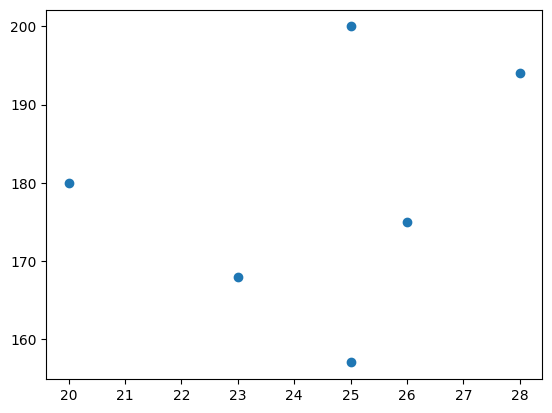

In [4]:
plt.scatter(idade,altura)

In [5]:
px.scatter(x  = idade, y = altura)

Caso queira salvar o gráfico

In [6]:
fig = px.scatter(x  = idade, y = altura)

In [7]:
fig.write_html('scatter.html')

In [8]:
#!pip install -U kaleido

In [9]:
import kaleido

In [10]:
#pip install --upgrade plotly

In [12]:
#fig.write_image('scatter.png', format = 'png')

Repare que para simplificar o trabalho o plotly já inicia com uma figura e área de desenho padrão, que você não precisa definir, e assim o código para gerar um gráfico pode ser simplesmente.  
Além disso, há diversas funcionalidades para interação com o gráfico plotado.

Vamos importar também outros pacotes padrões

In [13]:
import pandas as pd
import numpy as np

## Scatter (dispersão)
**Documentação**: https://plotly.com/python-api-reference/generated/plotly.express.scatter

In [14]:
z = ['a', 'b', 'c', 'd', 'e', 'f']
px.scatter(x  = idade, y = altura, color=z)

Importando o dataset dos pinguins

In [15]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [16]:
df_size = pd.read_csv('/content/drive/MyDrive/Python para Visualização/Dados/penguins_size.csv')
df_size.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [17]:
from plotly import data
px.scatter(data_frame=df_size, x = 'body_mass_g', y = 'culmen_depth_mm')

Vamos utilizar o matplotlib para obter o mesmo gráfico e assim podermos comparar visualmente as diferenças.

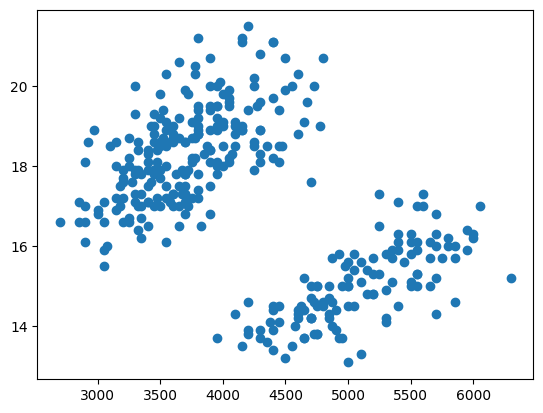

In [19]:
plt.scatter(x = df_size['body_mass_g'], y= df_size['culmen_depth_mm'])

Nota-se que a diferença visual entre os gráficos é enorme, porém a sintaxe que os gera não se diferencia tanto.

Podemos alterar as cores dos marcadores através de alguma variável do próprio dataframe como por exemplo o sexo dos pinguins.  
  
Por padrão o parâmetro *color* do px.scatter necessita de uma das colunas do próprio dataframe para realizar a marcação em cores das categorias.

In [20]:
df_size.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [21]:
df_size.dropna(inplace=True)

In [22]:
df_size.info()

<class 'pandas.core.frame.DataFrame'>
Index: 334 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            334 non-null    object 
 1   island             334 non-null    object 
 2   culmen_length_mm   334 non-null    float64
 3   culmen_depth_mm    334 non-null    float64
 4   flipper_length_mm  334 non-null    float64
 5   body_mass_g        334 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 20.9+ KB


In [28]:
df_size = df_size[~(df_size['sex'] == '.')]

In [31]:
px.scatter(data_frame=df_size, x = 'body_mass_g', y = 'culmen_depth_mm', color='species')

Estilizando o gráfico.

In [32]:
fig = px.scatter(data_frame=df_size, x = 'body_mass_g', y = 'culmen_depth_mm', color='sex')
fig.update_layout(template = 'presentation')

In [36]:
fig = px.scatter(data_frame=df_size, x = 'body_mass_g', y = 'culmen_depth_mm', color='sex')
fig.update_layout(
    xaxis_title = {'text': 'Massa corporal (g)', 'font_size': 18},
    yaxis_title = {'text': 'Altura do bico (mm)', 'font_size': 18},
    legend_title = {'text': 'Sexo', 'font_size': 18},
    font_color = 'grey',
    title = {'text': 'Massa dos pinguins em função da altura do bico', 'font_family':'Times New Roman', 'font_color':'black', 'font_size': 20},
    template = 'presentation')

Algumas strings que podem ser utilizadas no template:

| Template       | Descrição                                                                                                    |
| -------------- | ------------------------------------------------------------------------------------------------------------ |
| `ggplot2`      | Imita o estilo do pacote **ggplot2** do R — fundo cinza claro, grades brancas e visual mais acadêmico.       |
| `seaborn`      | Inspira-se na biblioteca **Seaborn** do Python — visual limpo, com cores suaves e grade leve.                |
| `simple_white` | Fundo **branco puro**, sem bordas nem cores de fundo extras — ideal para apresentações e relatórios.         |
| `plotly`       | O **tema padrão** do Plotly (modo claro), com fundo cinza claro e grades visíveis.                           |
| `plotly_white` | Fundo totalmente **branco**, com grades suaves — parecido com o `simple_white`, mas um pouco mais elaborado. |
| `plotly_dark`  | Tema **escuro**, com fundo preto e textos claros — ótimo para dashboards modernos.                           |
| `presentation` | Tema otimizado para **apresentações** — cores equilibradas, fontes mais legíveis e contraste ajustado.       |
| `xgridoff`     | Remove **as linhas de grade no eixo X**.                                                                     |
| `ygridoff`     | Remove **as linhas de grade no eixo Y**.                                                                     |
| `gridon`       | Garante que **as grades dos eixos fiquem ligadas**, mesmo que outro tema as tenha desligado.                 |
| `none`         | Nenhum estilo aplicado — o gráfico fica com aparência “crua”, sem formatação.                                |


## Linhas
**Documentação**: https://plotly.com/python-api-reference/generated/plotly.express.line

In [37]:
df_supermarket = pd.read_csv('/content/drive/MyDrive/Python para Visualização/Dados/supermarket_sales.csv')
df_supermarket.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


In [38]:
df_supermarket.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

In [39]:
df_supermarket.describe()

,Unit price,Quantity,Tax 5%,Total,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1.000000e+03,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905e+00,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,6.131498e-14,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905e+00,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905e+00,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905e+00,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905e+00,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905e+00,49.650000,10.00000


In [40]:
#Transformando a data em datetime
df_supermarket['Date'] = pd.to_datetime(df_supermarket['Date'])

In [41]:
df_supermarket.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Invoice ID               1000 non-null   object        
 1   Branch                   1000 non-null   object        
 2   City                     1000 non-null   object        
 3   Customer type            1000 non-null   object        
 4   Gender                   1000 non-null   object        
 5   Product line             1000 non-null   object        
 6   Unit price               1000 non-null   float64       
 7   Quantity                 1000 non-null   int64         
 8   Tax 5%                   1000 non-null   float64       
 9   Total                    1000 non-null   float64       
 10  Date                     1000 non-null   datetime64[ns]
 11  Time                     1000 non-null   object        
 12  Payment                  1000 non-n

In [42]:
px.line(df_supermarket, x = 'Date', y = 'Total')

In [43]:
df_supermarket['Date'].duplicated()

,Date
0,False
1,False
2,False
3,False
4,False
...,...
995,True
996,True
997,True
998,True


In [44]:
df_total = df_supermarket.pivot_table(index = 'Date', values= 'Total', aggfunc='sum')

In [45]:
df_total

,Total
Date,
2019-01-01,4745.1810
2019-01-02,1945.5030
2019-01-03,2078.1285
2019-01-04,1623.6885
2019-01-05,3536.6835
...,...
2019-03-26,1962.5130
2019-03-27,2902.8195
2019-03-28,2229.4020


In [46]:
fig = px.line(x = df_total.index, y=df_total['Total'])
fig.update_layout(
    xaxis_title = {'text': 'Data', 'font_size': 18},
    yaxis_title = {'text': 'Total somado', 'font_size': 18},
    font_color = 'grey',
    title = {'text': 'Total de vendas ao longo do tempo', 'font_family':'Times New Roman', 'font_color':'black', 'font_size': 20},
    template = 'presentation'
)

**No mesmo Eixo**

In [47]:
df_payment = df_supermarket.pivot_table(index = 'Date', values= 'Total', columns = 'Payment', aggfunc='sum')

In [48]:
df_payment

Payment,Cash,Credit card,Ewallet
Date,,,
2019-01-01,1933.8690,2513.6580,297.6540
2019-01-02,926.2260,756.8190,262.4580
2019-01-03,142.4010,952.6965,983.0310
2019-01-04,474.4530,776.0655,373.1700
2019-01-05,263.1300,1885.9680,1387.5855
...,...,...,...
2019-03-26,467.8485,753.7425,740.9220
2019-03-27,1201.2840,829.2375,872.2980
2019-03-28,632.3730,854.5425,742.4865


In [49]:
px.line(df_payment)

Podemos estilizar o gráfico

In [50]:
fig = px.line(df_payment, title = 'Vendas no supermercado por meio de pagamento ao longo do tempo')
fig.update_layout(
    xaxis_title = {'text': 'Data', 'font_size': 18},
    yaxis_title = {'text': 'Total somado', 'font_size': 18},
    legend_title = {'text': 'Método de pagamento', 'font_size': 18},
    font_color = 'grey',
    template = 'presentation'
)

**Em vários eixos**  
Para realizar o plot do gráfico acima, porém agora em três gráficos separados, o Plotly Express possui um parâmetro chamado *facet_col* e *facet_row* cujas funções é manter os gráficos em face com outros, seja pela linha (horizontal), seja pela coluna (vertical). Estes parâmetros necessitam de alguma coluna do DataFrame da qual será separado o gráfico, de forma semelhante como é feito utilizando o parâmetro color.

In [51]:
px.line(df_payment, facet_col = 'Payment')

Agora um exemplo do uso do *facet_row*, ou seja, uso dos gráficos em face horizontalmente.

In [57]:
fig = px.line(df_payment, facet_row= 'Payment', markers = True)
#Função para retirada do texto padrão 'payment'
fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))
fig.update_layout(legend_title="Método de Pagamento")

## Pizza
**Documentação**: https://plotly.com/python-api-reference/generated/plotly.express.pie

In [58]:
df_pizza = df_supermarket.pivot_table(index = 'Branch', values = 'Quantity', aggfunc = 'sum')

In [59]:
df_pizza

,Quantity
Branch,
A,1859
B,1820
C,1831


In [60]:
px.pie(names=df_pizza.index, values=df_pizza['Quantity'])

In [62]:
fig = px.pie(names=df_pizza.index, values=df_pizza['Quantity'])
fig.update_layout(
    title = {'text':'Distribuição das quantidades de vendas por marcas', 'x': 0.5}
)

## Barras
**Documentação**: https://plotly.com/python-api-reference/generated/plotly.express.bar.html

In [63]:
px.bar(df_pizza)

In [64]:
df_bar = df_supermarket.pivot_table(index = 'Branch', values = 'Total', columns = 'Gender', aggfunc = 'sum')

In [65]:
px.bar(df_bar)

In [66]:
fig = px.bar(df_bar)
fig.update_layout(
    xaxis_title = 'Marca',
    yaxis_title = 'Total de vendas (R$)',
    legend_title = 'Gênero',
    title = {'text':'Distribuição das quantidades de vendas por marcas', 'x': 0.5}
)

In [67]:
fig = px.bar(df_bar, barmode='group')
fig.update_layout(
    xaxis_title = 'Marca',
    yaxis_title = 'Total de vendas (R$)',
    legend_title = 'Gênero',
    title = {'text':'Distribuição das quantidades de vendas por marcas', 'x': 0.5}
)

**Barras Horizontais**
Para criar o gráfico de barras horizontais basta utilizar o parâmetro *orientation* como sendo 'h'

In [68]:
fig = px.bar(df_bar, barmode='group', orientation='h')
fig.update_layout(
    xaxis_title = 'Marca',
    yaxis_title = 'Total de vendas (R$)',
    legend_title = 'Gênero',
    title = {'text':'Distribuição das quantidades de vendas por marcas', 'x': 0.5}
)

## Histograma
**Documentação**: https://plotly.github.io/plotly.py-docs/generated/plotly.express.histogram.html

In [69]:
px.histogram(df_size, 'body_mass_g', nbins = 50)

In [70]:
px.histogram(df_size, 'body_mass_g', nbins = 50, marginal='box')

## Boxplot
**Documentação**: https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.boxplot.html

In [71]:
fig = px.box(data_frame=df_size, y = 'body_mass_g')

fig.update_layout(
    yaxis_title = 'Massa corporal (g)',
    title = {'text':'Boxplot da massa corporal', 'x': 0.5}
)

In [72]:
fig = px.box(data_frame=df_size, x = 'body_mass_g')

fig.update_layout(
    yaxis_title = 'Massa corporal (g)',
    title = {'text':'Boxplot da massa corporal', 'x': 0.5}
)

Retomando o gráfico de dispersão do início da aula

In [73]:
px.scatter(data_frame=df_size, x = 'body_mass_g', y = 'culmen_depth_mm')

É possível automaticamente concatenar gráficos

In [74]:
px.scatter(data_frame=df_size, x = 'body_mass_g', y = 'culmen_depth_mm', marginal_x='box', marginal_y='box')